In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/la-liga/E0 Season 2023-2024.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


2025-07-26 08:45:39.137597: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753519539.375453      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753519539.445920      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
df=pd.read_csv("/kaggle/input/la-liga/E0 Season 2023-2024.csv")
ar_index = df.columns.get_loc('AR')
df = df.iloc[:, :ar_index + 1]

In [5]:
df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,1,8,11,8,6,5,0,0,1,0
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,7,2,12,12,8,3,2,2,0,0
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,5,3,9,14,10,4,1,4,0,0
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,12,3,11,12,6,7,2,2,0,0
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,9,2,12,6,10,4,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,E0,19/05/2024,16:00,Crystal Palace,Aston Villa,5,0,H,2,0,...,9,2,10,8,2,4,1,4,0,0
376,E0,19/05/2024,16:00,Liverpool,Wolves,2,0,H,2,0,...,14,3,14,11,10,2,1,1,0,1
377,E0,19/05/2024,16:00,Luton,Fulham,2,4,A,1,2,...,6,7,15,20,4,4,5,4,0,0
378,E0,19/05/2024,16:00,Man City,West Ham,3,1,H,2,1,...,12,2,3,12,11,2,0,1,0,0


In [6]:
# Feature engineering - we'll select relevant features
features = ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
target = 'FTR'

# Encode the target variable
le = LabelEncoder()
df[target] = le.fit_transform(df[target])  # 0: Away Win, 1: Draw, 2: Home Win


In [7]:
# Split into features and target
X = df[features]
y = df[target]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-26 08:45:53.921467: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.2586 - loss: 1.7925 - val_accuracy: 0.2105 - val_loss: 1.0977 - learning_rate: 0.0010
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3988 - loss: 1.4900 - val_accuracy: 0.4079 - val_loss: 1.0498 - learning_rate: 0.0010
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4133 - loss: 1.3762 - val_accuracy: 0.5921 - val_loss: 1.0009 - learning_rate: 0.0010
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4720 - loss: 1.2910 - val_accuracy: 0.6579 - val_loss: 0.9503 - learning_rate: 0.0010
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5261 - loss: 1.1556 - val_accuracy: 0.6842 - val_loss: 0.9005 - learning_rate: 0.0010
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5722 - loss: 0.9635 - val_accuracy: 0.7105 - val_loss: 0.8596 - learning_rate: 0.0010
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5378 - loss: 0.9994 - val_accuracy

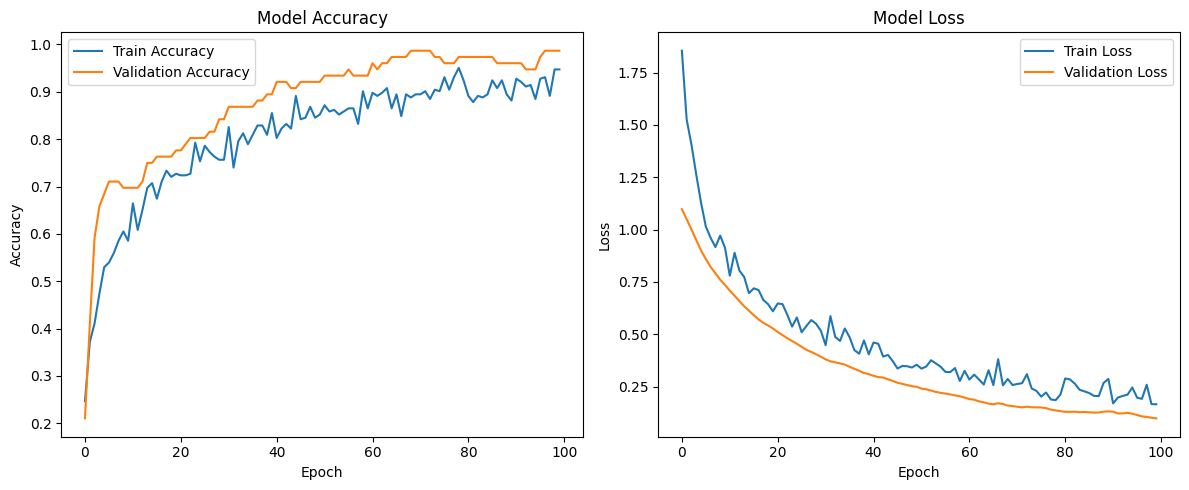

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Classification Report:
              precision    recall  f1-score   support

    Away Win       1.00      1.00      1.00        25
        Draw       1.00      0.94      0.97        16
    Home Win       0.97      1.00      0.99        35

    accuracy                           0.99        76
   macro avg       0.99      0.98      0.98        76
weighted avg       0.99      0.99      0.99        76


Confusion Matrix:


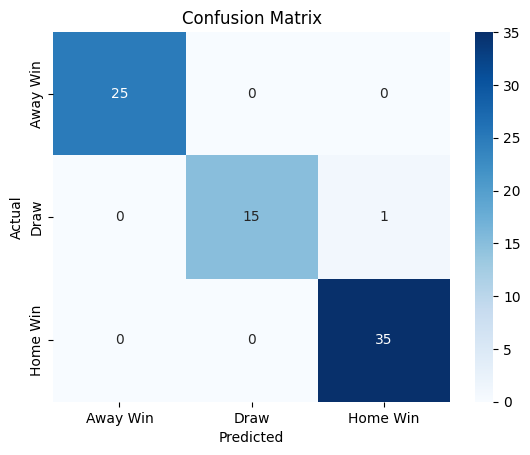

In [8]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert target to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# Build the deep learning model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(3, activation='softmax')  # 3 output classes
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# Train the model
history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_test_scaled, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")


# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report and confusion matrix
print("\nClassification Report:")
class_names = ['Away Win', 'Draw', 'Home Win']  # Must match LabelEncoder's class order
print(classification_report(y_test, y_pred_classes, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Training Fold 1/5...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Validation Accuracy: 0.8852

Training Fold 2/5...
Fold 2 Validation Accuracy: 0.9344

Training Fold 3/5...
Fold 3 Validation Accuracy: 0.8361

Training Fold 4/5...
Fold 4 Validation Accuracy: 0.8197

Training Fold 5/5...
Fold 5 Validation Accuracy: 0.9000

Cross-Validation Results:
Mean Accuracy: 0.8751 (±0.0420)
Individual Fold Accuracies: [0.8852, 0.9344, 0.8361, 0.8197, 0.9]

Training final model on full training set...
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.2855 - loss: 1.5334 - val_accuracy: 0.3289 - val_loss: 1.1799 - learning_rate: 0.0010
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3616 - loss: 1.3617 - val_accuracy: 0.4342 - val_loss: 1.0994 - learning_rate: 0.0010
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4162 - loss: 1.3407 - val_accuracy: 0.5395 - val_loss: 1.0275 - learning_rate: 0.0010
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5058 - loss: 1.0797 - val_accuracy: 0.5921 -

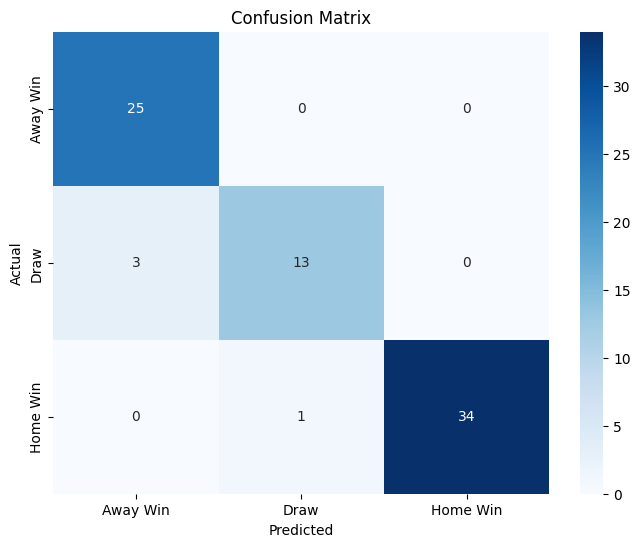

In [9]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define model creation function
def create_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return model

# Initialize KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results
cv_scores = []
fold = 1

# Cross-validation
for train_idx, val_idx in kfold.split(X_train_scaled):
    print(f"\nTraining Fold {fold}/5...")
    
    # Get fold data
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_cat[train_idx], y_train_cat[val_idx]
    
    # Create and train model
    model = create_model()
    history = model.fit(X_train_fold, y_train_fold,
                       validation_data=(X_val_fold, y_val_fold),
                       epochs=50,
                       batch_size=32,
                       verbose=0,
                       callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
    
    # Evaluate
    _, val_acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(val_acc)
    print(f"Fold {fold} Validation Accuracy: {val_acc:.4f}")
    fold += 1

# Print CV results
print("\nCross-Validation Results:")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"Individual Fold Accuracies: {[round(acc, 4) for acc in cv_scores]}")

# Train final model on full training set
print("\nTraining final model on full training set...")
final_model = create_model()
history = final_model.fit(X_train_scaled, y_train_cat,
                         epochs=100,
                         batch_size=32,
                         validation_data=(X_test_scaled, y_test_cat),
                         callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                   ReduceLROnPlateau(factor=0.2, patience=5)],
                         verbose=1)

# Evaluate on test set
test_loss, test_acc = final_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Classification report
y_pred = final_model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = ['Away Win', 'Draw', 'Home Win']
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

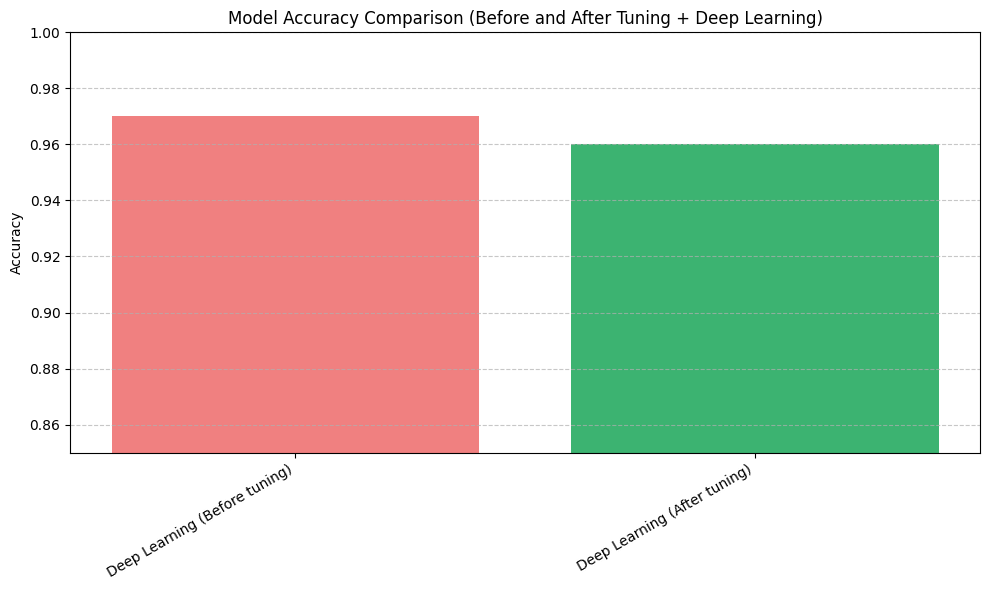

In [10]:
import matplotlib.pyplot as plt

# Define the accuracies
accuracies = {
    "Deep Learning (Before tuning)": 0.97,
    "Deep Learning (After tuning)": 0.96
}

# Plot
plt.figure(figsize=(10, 6))
plt.bar(accuracies.keys(), accuracies.values(), color=[ 'lightcoral', 'mediumseagreen', 'seagreen'])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Before and After Tuning + Deep Learning)")
plt.ylim(0.85, 1.0)  # adjust as needed
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
